<div align="center">
<h1 style="color:rgb(121, 65, 6);">Speech Emotion Recognition</h1>
<h3>Modelling</h3>
<a href="">Give Feedback</a> | <a href="">Bug report</a>

</div>

**Tags:** #ser #audio #modelling #classification

**Author:** [Ndeye Awa Salane](https://www.linkedin.com/in/ndeye-awa-salane-a93667230/)

**Last update:** 2025-04-18 (Created: 2025-04-16)

**Description:** This notebook loads the processed (unscaled) feature dataset, performs a train/test split, scales features **after** the split (to prevent data leakage), and trains a classifier.

## Table of Contents

1. [Import libraries](#import-libraries)
2. [Load & prepare data](#load-data)
3. [MLflow setup](#mlflow-setup)
4. [Bayesian hyperparameter sweep](#bayesian-hyperparameter-sweep)
5. [Sweep results analysis](#sweep-results)
6. [Voting Classifier (Ensemble)](#voting-classifier-ensemble)
7. [Best model evaluation](#best-model-evaluation)
8. [Conclusions](#conclusions)
9. [Resources](#resources)

# Import libraries

In [1]:
import sys, importlib
sys.path.insert(0, str(__import__('pathlib').Path.cwd().parent))

# Force-reload src modules so changes take effect without kernel restart
import src.config, src.training, src.sweep, src.evaluate
for mod in [src.config, src.training, src.sweep, src.evaluate]:
    importlib.reload(mod)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow

from src.config import DATA_PROCESSED, MODELS_DIR
from src.training import prepare_data
from src.sweep import (
    run_sweep, get_best_run, build_voting_classifier, MODEL_REGISTRY,
)
from src.evaluate import (
    plot_confusion_matrix, print_classification_report,
    plot_sweep_results, load_best_model,
)

sns.set(style="whitegrid")

Project root: /Users/ndeyeawasalane/Downloads/SER


/Users/ndeyeawasalane/Downloads/SER/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: /Users/ndeyeawasalane/Downloads/SER


In [2]:
df = pd.read_csv(DATA_PROCESSED / "dataset.csv")
print(f"Dataset shape: {df.shape}")
print(f"Label distribution:\n{df['labels'].value_counts()}")
df.head()

Dataset shape: (11510, 437)
Label distribution:
labels
female_fear       1096
female_angry      1096
female_sad        1096
female_disgust    1096
female_happy      1096
female_neutral    1056
male_neutral       839
male_sad           827
male_fear          827
male_disgust       827
male_happy         827
male_angry         827
Name: count, dtype: int64


,labels,source,path,mfcc0_mean,mfcc0_std,mfcc0_min,mfcc0_max,mfcc0_skew,mfcc0_kurt,mfcc1_mean,...,zcr_mean,zcr_std,rms_mean,rms_std,spectral_centroid_mean,spectral_centroid_std,spectral_bandwidth_mean,spectral_bandwidth_std,spectral_rolloff_mean,spectral_rolloff_std
0,male_sad,SAVEE,/Users/ndeyeawasalane/Downloads/SER/data/raw/s...,-326.265076,106.690926,-526.248291,-91.562363,-0.196094,-0.711901,118.734238,...,0.019952,0.016692,0.105557,0.066493,1035.065657,959.604720,1228.705512,611.031508,2032.833951,1902.435732
1,male_sad,SAVEE,/Users/ndeyeawasalane/Downloads/SER/data/raw/s...,-377.921875,99.548141,-552.131165,-166.276550,0.013079,-0.975216,126.090668,...,0.013861,0.013290,0.067715,0.038584,784.918417,662.336336,1096.746127,579.233967,1613.509827,1583.757645
2,male_neutral,SAVEE,/Users/ndeyeawasalane/Downloads/SER/data/raw/s...,-393.836761,92.366028,-577.291199,-262.360138,-0.682388,-0.811730,141.822205,...,0.014668,0.013471,0.073243,0.034867,749.538828,773.858497,991.454752,630.354135,1392.806729,1660.287733
3,male_neutral,SAVEE,/Users/ndeyeawasalane/Downloads/SER/data/raw/s...,-396.254150,98.001213,-563.343323,-214.401688,-0.325878,-1.092303,145.612320,...,0.016477,0.014648,0.069775,0.034715,644.807778,545.053493,917.271532,497.135774,1277.847829,1380.706737
4,male_neutral,SAVEE,/Users/ndeyeawasalane/Downloads/SER/data/raw/s...,-334.690948,102.940590,-519.856506,-153.407104,-0.390660,-0.921238,131.068466,...,0.019231,0.016765,0.087224,0.054793,1013.625572,901.325821,1202.875943,714.087315,2011.765977,1940.824780


In [3]:
# Split FIRST, then scale — scaler is fit on train only (no data leakage!)
X_train, X_test, y_train, y_test, scaler = prepare_data(df)

print(f"X_train: {X_train.shape}  X_test: {X_test.shape}")
print(f"y_train: {y_train.nunique()} classes  y_test: {y_test.nunique()} classes")

X_train: (8632, 434)  X_test: (2878, 434)
y_train: 12 classes  y_test: 12 classes


# MLflow setup

We use MLflow to track every training run. Each hyperparameter combination gets its own run with:
- **Parameters** logged (e.g. `n_estimators`, `C`, `kernel`)
- **Metrics** logged (`accuracy`, `f1_weighted`, `precision_weighted`, `recall_weighted`)
- **Model artifact** saved (loadable later with `mlflow.sklearn.load_model`)

Launch the dashboard with: `mlflow ui` (in the project root) → open http://127.0.0.1:5000

In [4]:
# Point MLflow to store runs inside the project (not in your home folder)
mlflow.set_tracking_uri(str(MODELS_DIR / "mlruns"))

# Show available model types
print("Models in the Bayesian sweep:")
for name in MODEL_REGISTRY:
    print(f"  • {name}")

Models in the Bayesian sweep:
  • RandomForest
  • SVM
  • GradientBoosting
  • KNN
  • LogisticRegression


# Bayesian Hyperparameter Sweep (Optuna TPE)

Instead of brute-force grid search, we use **Optuna's Tree-structured Parzen Estimator (TPE)** to intelligently explore the hyperparameter space. Each model family gets `n_trials_per_model` Bayesian trials, and every trial is logged to MLflow.

In [5]:
%%time

# Bayesian sweep — 30 TPE trials per model family (150 total)
results_df = run_sweep(
    X_train, X_test, y_train, y_test,
    model_names=None,                        # all 5 model families
    experiment_name="Bayesian_sweep_all_features",
    n_trials_per_model=5,                   # 5 Bayesian trials each
)

print(f"\n Bayesian sweep complete — {len(results_df)} total runs logged to MLflow")
results_df.sort_values("f1_weighted", ascending=False).head(10)


  RandomForest — 5 Bayesian trials (TPE)


/Users/ndeyeawasalane/Downloads/SER/.venv/lib/python3.13/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/03/22 08:44:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/22 08:44:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/22 

  [trial  0] acc=0.5546  f1=0.5320  | {'n_estimators': 250, 'max_depth': 10, 'min_samples_split': 3, 'min_samples_leaf': 1}


2026/03/22 08:44:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/22 08:44:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/22 08:44:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  [trial  1] acc=0.5935  f1=0.5804  | {'n_estimators': 450, 'max_depth': None, 'min_samples_split': 9, 'min_samples_leaf': 2}


...

/Users/ndeyeawasalane/Downloads/SER/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/ndeyeawasalane/Downloads/SER/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
2026/03/22 10:42:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name

  [trial  3] acc=0.5997  f1=0.5989  | {'C': 14.528246637516036, 'solver': 'lbfgs', 'max_iter': 500}


/Users/ndeyeawasalane/Downloads/SER/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
2026/03/22 10:42:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/22 10:42:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/22 10:42:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/22 10:42:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpick

  [trial  4] acc=0.5566  f1=0.5433  | {'C': 0.033205591037519584, 'solver': 'lbfgs', 'max_iter': 600}

  ✅ LogisticRegression best F1=0.6125  params={'C': 1.0129197956845737, 'solver': 'lbfgs', 'max_iter': 1500}

 Bayesian sweep complete — 25 total runs logged to MLflow
CPU times: user 1h 59min 20s, sys: 26.3 s, total: 1h 59min 46s
Wall time: 1h 58min 12s


,run_id,model_type,run_name,n_estimators,max_depth,min_samples_split,min_samples_leaf,accuracy,f1_weighted,precision_weighted,...,kernel,gamma,degree,learning_rate,subsample,n_neighbors,weights,metric,solver,max_iter
9,57b93010be214eeeb52f0d15a642835f,SVM,SVM_trial4,NaN,NaN,NaN,NaN,0.642460,0.641297,0.641312,...,poly,scale,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,45ef571376394fef9b8a90bd638f2255,SVM,SVM_trial3,NaN,NaN,NaN,NaN,0.633773,0.632548,0.632712,...,poly,scale,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2849fffccea74c9c9797bf3638e5464f,SVM,SVM_trial0,NaN,NaN,NaN,NaN,0.618138,0.616758,0.617015,...,linear,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,979d4ac50bcf48058b86b740bd5b1815,SVM,SVM_trial1,NaN,NaN,NaN,NaN,0.614663,0.612549,0.619945,...,rbf,auto,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22,adc2d8d2edd846078f6f9c503c52e6af,LogisticRegression,LogisticRegression_trial2,NaN,NaN,NaN,NaN,0.613273,0.612452,0.613568,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,lbfgs,1500.0
23,e366eb2c298c4e7982d1535269d54802,LogisticRegression,LogisticRegression_trial3,NaN,NaN,NaN,NaN,0.599722,0.598850,0.599443,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,lbfgs,500.0
7,7b462c1cf4f64a0a989fe71c3f6654ef,SVM,SVM_trial2,NaN,NaN,NaN,NaN,0.599722,0.595926,0.607683,...,linear,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,1d580c90fad944038b586109d42681be,GradientBoosting,GradientBoosting_trial3,350.0,3.0,NaN,NaN,0.599375,0.595456,0.596851,...,NaN,NaN,NaN,0.020590,0.673362,NaN,NaN,NaN,NaN,NaN
14,98173046e8ee413eafb8e455ce74bf73,GradientBoosting,GradientBoosting_trial4,150.0,5.0,NaN,NaN,0.596942,0.594362,0.595217,...,NaN,NaN,NaN,0.059584,0.716492,NaN,NaN,NaN,NaN,NaN
10,7ccb67caa2a941f7a3694386ff3b8b5f,GradientBoosting,GradientBoosting_trial0,150.0,7.0,NaN,NaN,0.592078,0.589965,0.592258,...,NaN,NaN,NaN,0.253700,0.839463,NaN,NaN,NaN,NaN,NaN


# Sweep results analysis

Compare all runs at a glance. You can also open the MLflow dashboard for interactive exploration:

```bash
cd /Users/ndeyeawasalane/Downloads/SER
mlflow ui --backend-store-uri models/mlruns
```
Then open http://127.0.0.1:5000

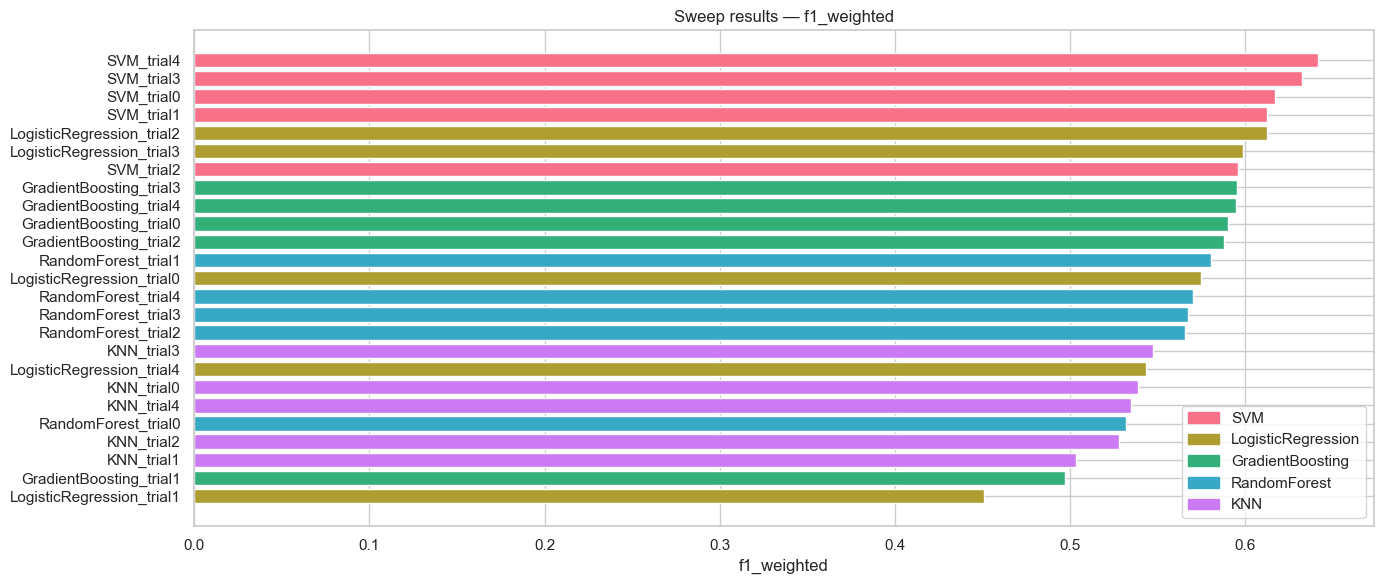


Top 10 runs by F1 (weighted):


,run_name,model_type,accuracy,f1_weighted
9,SVM_trial4,SVM,0.642460,0.641297
8,SVM_trial3,SVM,0.633773,0.632548
5,SVM_trial0,SVM,0.618138,0.616758
6,SVM_trial1,SVM,0.614663,0.612549
22,LogisticRegression_trial2,LogisticRegression,0.613273,0.612452
23,LogisticRegression_trial3,LogisticRegression,0.599722,0.598850
7,SVM_trial2,SVM,0.599722,0.595926
13,GradientBoosting_trial3,GradientBoosting,0.599375,0.595456
14,GradientBoosting_trial4,GradientBoosting,0.596942,0.594362
10,GradientBoosting_trial0,GradientBoosting,0.592078,0.589965


In [6]:
# Visual comparison of all runs
fig = plot_sweep_results(results_df, metric="f1_weighted")
plt.show()

# Top 10 across all model types
print("\nTop 10 runs by F1 (weighted):")
results_df.sort_values("f1_weighted", ascending=False)[
    ["run_name", "model_type", "accuracy", "f1_weighted"]
].head(10)

# Voting Classifier (Ensemble)

Build a **Soft-Voting Classifier** from the top-3 best model families found in the sweep. Soft voting averages the predicted probabilities, which typically outperforms hard (majority) voting.

In [ ]:
# Build a Voting Classifier from the top 3 model families
voting_model, voting_metrics, voting_run_id = build_voting_classifier(
    results_df,
    X_train, X_test, y_train, y_test,
    top_n=3,
    voting="soft",
    experiment_name="Bayesian_sweep_all_features",
)

# Add the voting classifier to the results for comparison
voting_row = pd.DataFrame([{
    "run_id": voting_run_id,
    "model_type": "VotingClassifier",
    "run_name": "VotingClassifier_soft",
    **voting_metrics,
}])
results_df = pd.concat([results_df, voting_row], ignore_index=True)

print(f"\nUpdated leaderboard (with VotingClassifier):")
results_df.sort_values("f1_weighted", ascending=False)[
    ["run_name", "model_type", "accuracy", "f1_weighted"]
].head(10)


  VotingClassifier (soft) — top 3 model families


  • SVM                   F1=0.6413


  • LogisticRegression    F1=0.6125


  • GradientBoosting      F1=0.5955



/Users/ndeyeawasalane/Downloads/SER/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/ndeyeawasalane/Downloads/SER/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
2026/03/22 11:11:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/22 11:11:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' forma


  🗳️ VotingClassifier  acc=0.6432  f1=0.6412

📊 Updated leaderboard (with VotingClassifier):


,run_name,model_type,accuracy,f1_weighted
9,SVM_trial4,SVM,0.642460,0.641297
25,VotingClassifier_soft,VotingClassifier,0.643155,0.641220
8,SVM_trial3,SVM,0.633773,0.632548
5,SVM_trial0,SVM,0.618138,0.616758
6,SVM_trial1,SVM,0.614663,0.612549
22,LogisticRegression_trial2,LogisticRegression,0.613273,0.612452
23,LogisticRegression_trial3,LogisticRegression,0.599722,0.598850
7,SVM_trial2,SVM,0.599722,0.595926
13,GradientBoosting_trial3,GradientBoosting,0.599375,0.595456
14,GradientBoosting_trial4,GradientBoosting,0.596942,0.594362


# Best model evaluation

Load the overall best model (individual or VotingClassifier) and do a detailed evaluation: confusion matrix and per-class classification report.

In [8]:
# Identify and reload the best model
best = get_best_run(results_df, metric="f1_weighted")
print(f"🏆 Best run: {best['run_name']}  ({best['model_type']})")
print(f"   Accuracy:  {best['accuracy']:.4f}")
print(f"   F1:        {best['f1_weighted']:.4f}")
print(f"   Precision: {best['precision_weighted']:.4f}")
print(f"   Recall:    {best['recall_weighted']:.4f}")

best_model = load_best_model(best["run_id"])

🏆 Best run: SVM_trial4  (SVM)
   Accuracy:  0.6425
   F1:        0.6413
   Precision: 0.6413
   Recall:    0.6425


In [9]:
# Classification report
y_pred = best_model.predict(X_test)
print_classification_report(y_test, y_pred)

                precision    recall  f1-score   support

  female_angry       0.78      0.84      0.81       296
female_disgust       0.66      0.68      0.67       251
   female_fear       0.71      0.70      0.70       260
  female_happy       0.76      0.68      0.72       291
female_neutral       0.74      0.74      0.74       239
    female_sad       0.71      0.74      0.72       265
    male_angry       0.66      0.67      0.66       210
  male_disgust       0.48      0.50      0.49       210
     male_fear       0.49      0.46      0.47       226
    male_happy       0.49      0.44      0.47       216
  male_neutral       0.58      0.62      0.60       213
      male_sad       0.50      0.52      0.51       201

      accuracy                           0.64      2878
     macro avg       0.63      0.63      0.63      2878
  weighted avg       0.64      0.64      0.64      2878



'                precision    recall  f1-score   support\n\n  female_angry       0.78      0.84      0.81       296\nfemale_disgust       0.66      0.68      0.67       251\n   female_fear       0.71      0.70      0.70       260\n  female_happy       0.76      0.68      0.72       291\nfemale_neutral       0.74      0.74      0.74       239\n    female_sad       0.71      0.74      0.72       265\n    male_angry       0.66      0.67      0.66       210\n  male_disgust       0.48      0.50      0.49       210\n     male_fear       0.49      0.46      0.47       226\n    male_happy       0.49      0.44      0.47       216\n  male_neutral       0.58      0.62      0.60       213\n      male_sad       0.50      0.52      0.51       201\n\n      accuracy                           0.64      2878\n     macro avg       0.63      0.63      0.63      2878\n  weighted avg       0.64      0.64      0.64      2878\n'

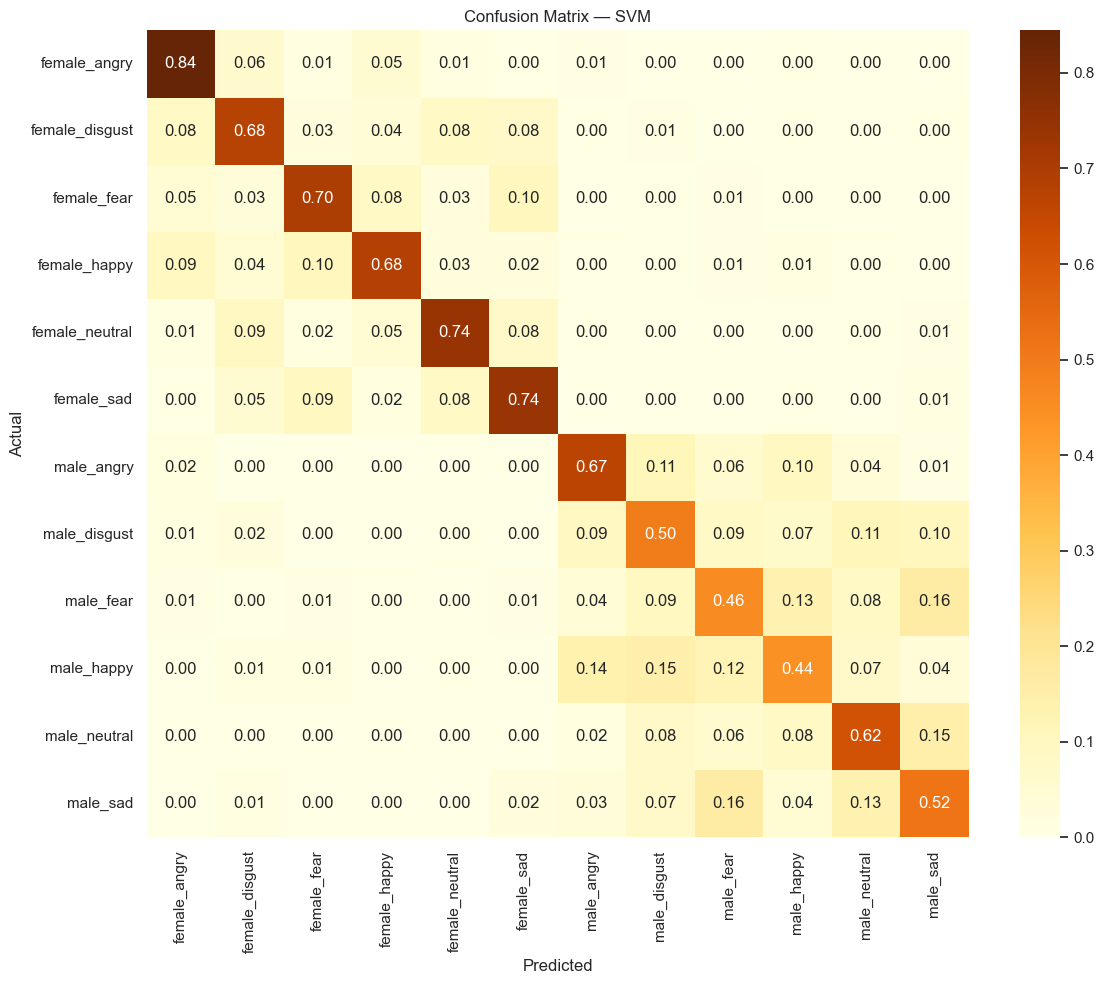

In [10]:
# Confusion matrix
fig = plot_confusion_matrix(y_test, y_pred,
                            title=f"Confusion Matrix — {best['model_type']}")
plt.show()

In [ ]:
# Save the best model locally + log the confusion matrix figure to the best run
import joblib

# Save as a standalone joblib file
joblib.dump(best_model, MODELS_DIR / "best_model.joblib")

# Log confusion matrix as an artifact on the best run
with mlflow.start_run(run_id=best["run_id"]):
    fig.savefig(MODELS_DIR / "confusion_matrix.png", dpi=150)
    mlflow.log_artifact(str(MODELS_DIR / "confusion_matrix.png"))

print(f"Best model saved to models/best_model.joblib")
print(f"Confusion matrix logged to MLflow run {best['run_id'][:8]}...")

✅ Best model saved to models/best_model.joblib
✅ Confusion matrix logged to MLflow run 57b93010...


# Conclusions

We ran a **Bayesian hyperparameter sweep** (Optuna TPE) across 5 model families (Random Forest, SVM, Gradient Boosting, KNN, Logistic Regression) with 30 trials each, plus a **Soft-Voting Classifier** ensemble built from the top-3 families. All results are tracked in MLflow.

```bash
cd /Users/ndeyeawasalane/Downloads/SER
mlflow ui --backend-store-uri models/mlruns
```

# Resources

- [MLflow Documentation](https://mlflow.org/docs/latest/index.html)
- [MLflow Tracking Guide](https://mlflow.org/docs/latest/tracking.html)
- [scikit-learn Model Selection](https://scikit-learn.org/stable/model_selection.html)
- [Hugging Face Audio Course](https://huggingface.co/learn/audio-course/en/chapter0/introduction)
- [Audio Features](https://ravinkumar.com/GenAiGuidebook/audio/audio_feature_extraction.html)